### Train the Predictive Maintenance Model

What we are building:

A model that looks at sensor readings and predicts:
"How many more cycles before this engine needs maintenance?"

Why random forest?

Random Forest is like asking 100 different experts to give
their opinion, then taking the average. It:
- Works well with sensor data
- Handles noise in readings
- Is easy to understand and explain
- Tells us which sensors matter most

We will also check for anomalies (unusual sensor behaviour)
using Isolation Forest -- a different kind of model.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# sklearn = scikit-learn — Python's most popular machine learning library
from sklearn.ensemble import RandomForestRegressor    # Our main prediction model
from sklearn.ensemble import IsolationForest          # For anomaly detection
from sklearn.preprocessing import MinMaxScaler        # To scale numbers to 0-1 range
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


### Load the processed data

In [3]:
print("Loading processed training data...")

# Check if processed file exists
if not os.path.exists("data/train_FD001_processed.csv"):
    print("ERROR: Processed data not found!")
    print("Please run 04_eda_features.ipynb first.")
else:
    data = pd.read_csv("data/train_FD001_processed.csv")
    print(f"Loaded {len(data):,} rows and {data.shape[1]} columns")
    print(f"Engines in dataset: {data['engine_id'].nunique()}")

Loading processed training data...
Loaded 20,631 rows and 38 columns
Engines in dataset: 100


#### Select which columns to use as inputs (features)

In [4]:
# Our MODEL INPUTS — the sensor readings we give to the model
input_features = [
    # Rolling averages (smoother than raw readings)
    "sensor_2_rolling_avg",
    "sensor_7_rolling_avg",
    "sensor_11_rolling_avg",
    "sensor_12_rolling_avg",
    # Rolling standard deviation (variability over time)
    "sensor_2_rolling_std",
    "sensor_7_rolling_std",
    "sensor_11_rolling_std",
    "sensor_12_rolling_std",
    # Raw useful sensors
    "sensor_3", "sensor_4", "sensor_8", "sensor_9",
    "sensor_13", "sensor_14", "sensor_15", "sensor_17",
    "sensor_20", "sensor_21",
    # Operational settings (flight conditions)
    "op_setting_1", "op_setting_2", "op_setting_3",
    # How far into engine life we are
    "cycle_ratio",
]

# Our MODEL OUTPUT — what we want to predict
target_column = "RUL_capped"   # Remaining Useful Life (capped at 125)

print(f"Input features: {len(input_features)}")
print(f"Target column:  {target_column}")

Input features: 22
Target column:  RUL_capped


####  Prepare X (inputs) and y (target)

- X = inputs (what the model SEES)
- y = output (what the model PREDICTS)

In [6]:
X = data[input_features]
y = data[target_column]

print(f"X shape: {X.shape}  (rows, features)")
print(f"y shape: {y.shape}  (rows,)")

X shape: (20631, 22)  (rows, features)
y shape: (20631,)  (rows,)


#### Scale the features (normalize to 0-1 range)
Different sensors have very different ranges.

Sensor_2 might be around 600, while sensor_12 might be 0.5.

Scaling makes everything equally visible to the model.

In [7]:
scaler = MinMaxScaler()   # Scales each feature to a 0-1 range
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=input_features)

print("Features scaled to 0-1 range using MinMaxScaler")

# Save the scaler — we need it later when making predictions on new data
os.makedirs("data", exist_ok=True)
joblib.dump(scaler, "data/scaler.pkl")
print("Scaler saved to: data/scaler.pkl")

Features scaled to 0-1 range using MinMaxScaler
Scaler saved to: data/scaler.pkl


#### Split data into training and validation sets

We hold back 20% of the data to TEST how good our model is.
The model NEVER sees this 20% during training.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y,
    test_size=0.2,        # 20% goes to validation
    random_state=42       # Ensures same split every run
)

print(f"Training set:   {X_train.shape[0]:,} rows (80%)")
print(f"Validation set: {X_val.shape[0]:,} rows (20%)")

Training set:   16,504 rows (80%)
Validation set: 4,127 rows (20%)


#### Train the Random Forest model

**n_estimators** = how many trees in the forest

**max_depth** = how deep each tree can go (prevents overfitting)

In [9]:
print("TRAINING THE RANDOM FOREST MODEL...")
print("(This may take 30-60 seconds)")

model = RandomForestRegressor(
    n_estimators=100,   # 100 decision trees
    max_depth=15,       # Each tree can make 15 levels of decisions
    min_samples_leaf=5, # Each leaf needs at least 5 samples
    random_state=42,
    n_jobs=-1           # Use all CPU cores to train faster
)

model.fit(X_train, y_train)
print("Training complete!")

TRAINING THE RANDOM FOREST MODEL...
(This may take 30-60 seconds)
Training complete!


#### Evaluate the model
Now we test the model on data it has NEVER seen (validation set)

In [11]:
print("MODEL EVALUATION")

# Make predictions on the validation set
y_predictions = model.predict(X_val)

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_val, y_predictions))
mae  = mean_absolute_error(y_val, y_predictions)
r2   = r2_score(y_val, y_predictions)

print(f"RMSE (Root Mean Square Error):   {rmse:.2f} cycles")
print(f"MAE  (Mean Absolute Error):      {mae:.2f} cycles")
print(f"R2   (Accuracy Score):           {r2:.4f}")
print("""
WHAT THESE NUMBERS MEAN:

RMSE = On average, our prediction is off by X cycles.
       Lower is better. Target: under 25 cycles.

MAE  = Similar to RMSE but less sensitive to big mistakes.
       Lower is better.

R2   = How much of the variation our model explains.
       1.0 = perfect, 0.0 = no better than guessing average.
       Target: above 0.85.
""")

# Save model
joblib.dump(model, "data/random_forest_model.pkl")
print("Model saved to: data/random_forest_model.pkl")

MODEL EVALUATION
RMSE (Root Mean Square Error):   7.23 cycles
MAE  (Mean Absolute Error):      4.38 cycles
R2   (Accuracy Score):           0.9692

WHAT THESE NUMBERS MEAN:

RMSE = On average, our prediction is off by X cycles.
       Lower is better. Target: under 25 cycles.

MAE  = Similar to RMSE but less sensitive to big mistakes.
       Lower is better.

R2   = How much of the variation our model explains.
       1.0 = perfect, 0.0 = no better than guessing average.
       Target: above 0.85.

Model saved to: data/random_forest_model.pkl


#### Chart: Predicted vs Actual RUL

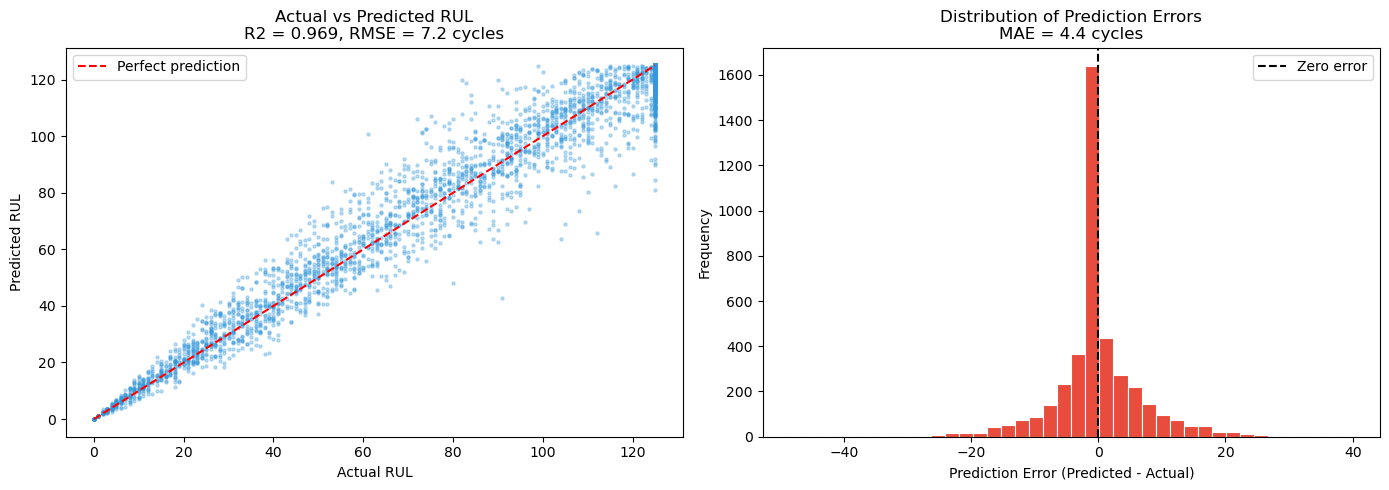

Chart saved: data/chart_04_model_performance.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Scatter plot — predicted vs actual
axes[0].scatter(y_val, y_predictions, alpha=0.3, s=5, color="#3498db")
perfect_line = [y_val.min(), y_val.max()]
axes[0].plot(perfect_line, perfect_line, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title(f"Actual vs Predicted RUL\nR2 = {r2:.3f}, RMSE = {rmse:.1f} cycles")
axes[0].legend()

# Chart 2: Error distribution
errors = y_predictions - y_val
axes[1].hist(errors, bins=40, color="#e74c3c", edgecolor="white", linewidth=0.8)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5, label="Zero error")
axes[1].set_xlabel("Prediction Error (Predicted - Actual)")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Distribution of Prediction Errors\nMAE = {mae:.1f} cycles")
axes[1].legend()

plt.tight_layout()
plt.savefig("data/chart_04_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: data/chart_04_model_performance.png")

### Feature Importance
Which sensors matter most for prediction?


FEATURE IMPORTANCE (Which sensors matter most?)

Top 10 most important features:
              feature  importance
          cycle_ratio    0.945393
 sensor_7_rolling_avg    0.006498
 sensor_2_rolling_avg    0.006010
 sensor_2_rolling_std    0.005521
sensor_12_rolling_std    0.005162
sensor_12_rolling_avg    0.005034
sensor_11_rolling_avg    0.004994
 sensor_7_rolling_std    0.004974
sensor_11_rolling_std    0.004234
            sensor_14    0.003839


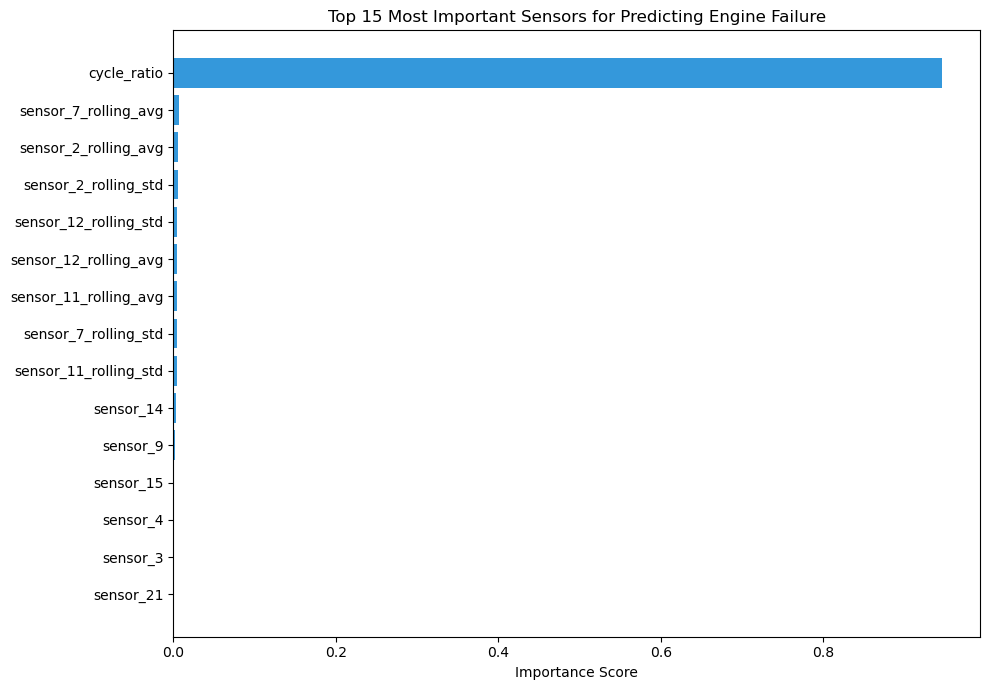

Chart saved: data/chart_05_feature_importance.png


In [13]:
print("FEATURE IMPORTANCE (Which sensors matter most?)")


# Random Forest can tell us how important each input feature was
importance_values = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": input_features,
    "importance": importance_values
}).sort_values("importance", ascending=False)

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

importance_df.to_csv("data/feature_importance.csv", index=False)

# Chart: Feature importance bar chart
top_15 = importance_df.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_15["feature"][::-1], top_15["importance"][::-1], color="#3498db")
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Most Important Sensors for Predicting Engine Failure")
plt.tight_layout()
plt.savefig("data/chart_05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: data/chart_05_feature_importance.png")

#### Anomaly Detection with Isolation Forest
An anomaly = a sensor reading that is VERY unusual.

- Anomaly detection asks: Is this reading NORMAL or WEIRD?

If a sensor suddenly spikes or drops, that could be a problem
even if the engine still has many cycles left.

In [14]:
print("ANOMALY DETECTION WITH ISOLATION FOREST")

# Train the anomaly detector on healthy engine readings
normal_readings = data[data["RUL_capped"] == 125][input_features]
print(f"Training anomaly detector on {len(normal_readings):,} healthy readings...")

iso_forest = IsolationForest(
    contamination=0.05,  # We expect 5% of readings to be anomalous
    random_state=42
)

iso_forest.fit(scaler.transform(normal_readings))
print("Anomaly detector trained!")

# Predict anomalies across ALL readings
all_X_scaled = scaler.transform(data[input_features])
anomaly_predictions = iso_forest.predict(all_X_scaled)
data["is_anomaly"] = anomaly_predictions == -1   # True if anomaly

anomaly_count = data["is_anomaly"].sum()
total_count = len(data)
anomaly_rate = anomaly_count / total_count * 100

print(f"\nAnomalies detected: {anomaly_count:,} out of {total_count:,} readings ({anomaly_rate:.1f}%)")

joblib.dump(iso_forest, "data/anomaly_detector.pkl")
print("Anomaly detector saved to: data/anomaly_detector.pkl")

ANOMALY DETECTION WITH ISOLATION FOREST
Training anomaly detector on 8,131 healthy readings...
Anomaly detector trained!

Anomalies detected: 7,815 out of 20,631 readings (37.9%)
Anomaly detector saved to: data/anomaly_detector.pkl


#### Chart: Where do anomalies appear in engine lifecycle?

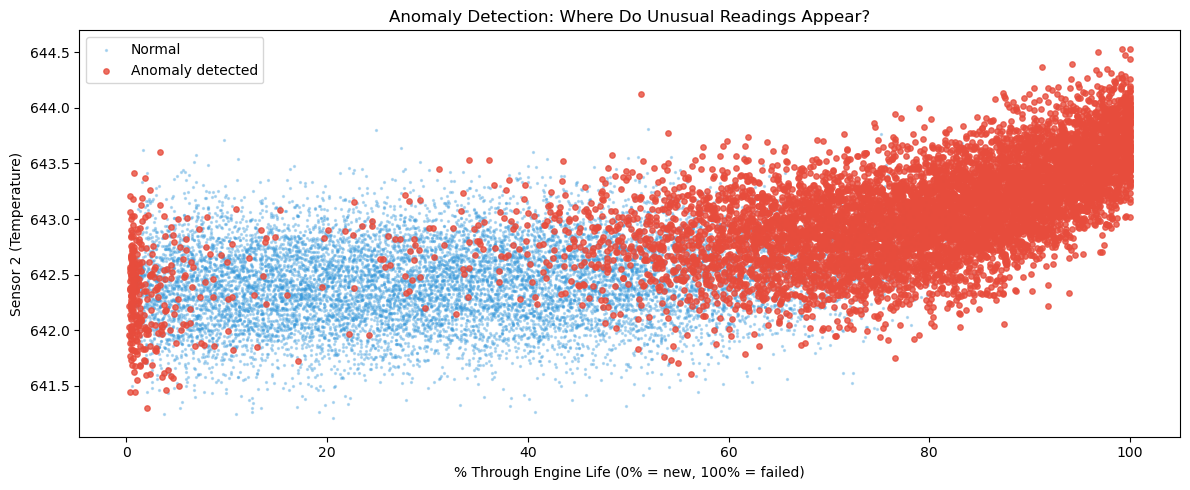

Chart saved: data/chart_06_anomalies.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

normal_points = data[data["is_anomaly"] == False]
anomaly_points = data[data["is_anomaly"] == True]

ax.scatter(normal_points["cycle_ratio"] * 100,
           normal_points["sensor_2"],
           s=2, alpha=0.3, color="#3498db", label="Normal")
ax.scatter(anomaly_points["cycle_ratio"] * 100,
           anomaly_points["sensor_2"],
           s=15, alpha=0.8, color="#e74c3c", label="Anomaly detected")

ax.set_xlabel("% Through Engine Life (0% = new, 100% = failed)")
ax.set_ylabel("Sensor 2 (Temperature)")
ax.set_title("Anomaly Detection: Where Do Unusual Readings Appear?")
ax.legend()
plt.tight_layout()
plt.savefig("data/chart_06_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: data/chart_06_anomalies.png")

#### Model Summary and Recommendations

In [17]:
print("MODEL SUMMARY & BUSINESS RECOMMENDATIONS")
print(f"""
RESULTS:

Model: Random Forest Regressor
Training samples: {len(X_train):,}
Validation samples: {len(X_val):,}

Performance:
  - RMSE: {rmse:.1f} cycles (average error)
  - MAE:  {mae:.1f} cycles
  - R2:   {r2:.3f}

WHAT THIS MEANS FOR THE BUSINESS:
1. PREDICTION ACCURACY:
   Our model can predict engine failure within ~{rmse:.0f} cycles on average.
   For maintenance planning, this allows scheduling work
   approximately {rmse:.0f} cycles ahead with confidence.

2. MOST CRITICAL SENSORS TO MONITOR:
   Focus on: {', '.join(importance_df['feature'].head(5).tolist())}
   If these sensors show unusual readings, trigger an alert.

3. COST SAVINGS POTENTIAL:
   Unplanned engine failures cost $500,000+ per incident.
   With ~{r2*100:.0f}% prediction accuracy, most failures can be
   predicted and prevented through scheduled maintenance.

4. ANOMALY DETECTION:
   {anomaly_rate:.1f}% of all readings flagged as unusual.
   These flagged readings deserve immediate engineer review.

""")

MODEL SUMMARY & BUSINESS RECOMMENDATIONS

RESULTS:

Model: Random Forest Regressor
Training samples: 16,504
Validation samples: 4,127

Performance:
  - RMSE: 7.2 cycles (average error)
  - MAE:  4.4 cycles
  - R2:   0.969

WHAT THIS MEANS FOR THE BUSINESS:
1. PREDICTION ACCURACY:
   Our model can predict engine failure within ~7 cycles on average.
   For maintenance planning, this allows scheduling work
   approximately 7 cycles ahead with confidence.

2. MOST CRITICAL SENSORS TO MONITOR:
   Focus on: cycle_ratio, sensor_7_rolling_avg, sensor_2_rolling_avg, sensor_2_rolling_std, sensor_12_rolling_std
   If these sensors show unusual readings, trigger an alert.

3. COST SAVINGS POTENTIAL:
   Unplanned engine failures cost $500,000+ per incident.
   With ~97% prediction accuracy, most failures can be
   predicted and prevented through scheduled maintenance.

4. ANOMALY DETECTION:
   37.9% of all readings flagged as unusual.
   These flagged readings deserve immediate engineer review.


